In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
pi = 3.14159265359

xtrue
ytrue


/tmp/ipykernel_1882807/1937697745.py:35: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_1882807/1937697745.py:35: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
xtrue
ytrue


...

angletrue
xtrue
ytrue


/tmp/ipykernel_1882807/1937697745.py:35: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_1882807/1937697745.py:35: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


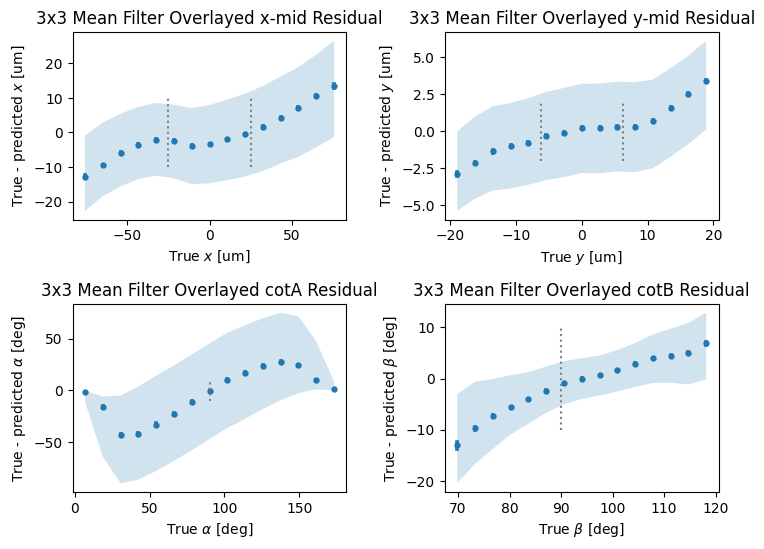

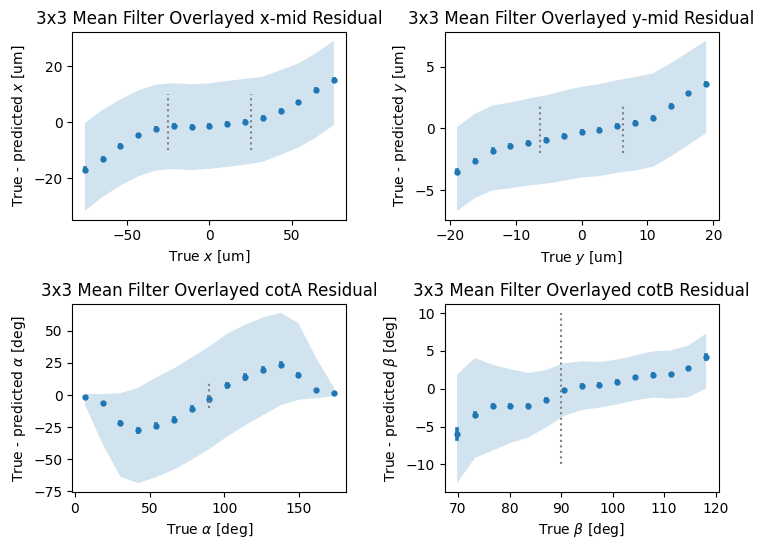

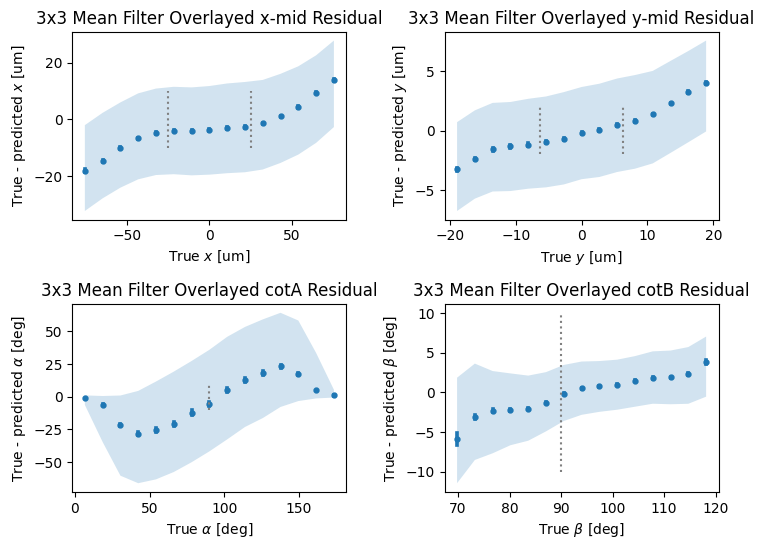

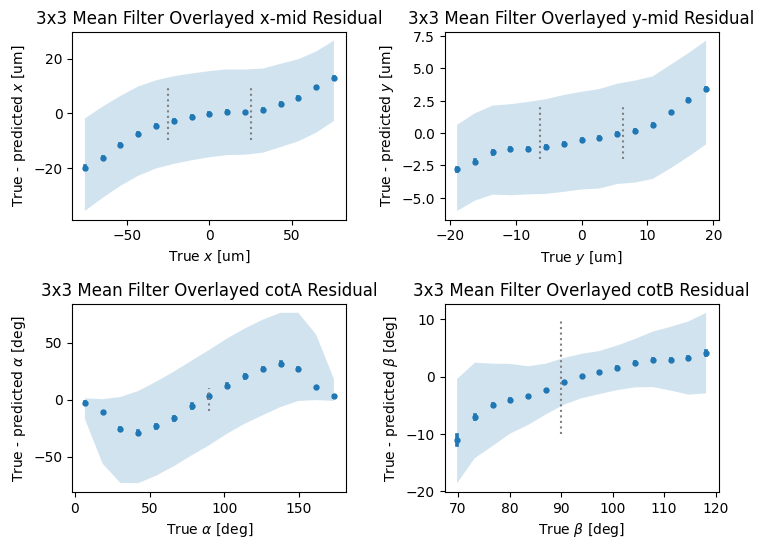

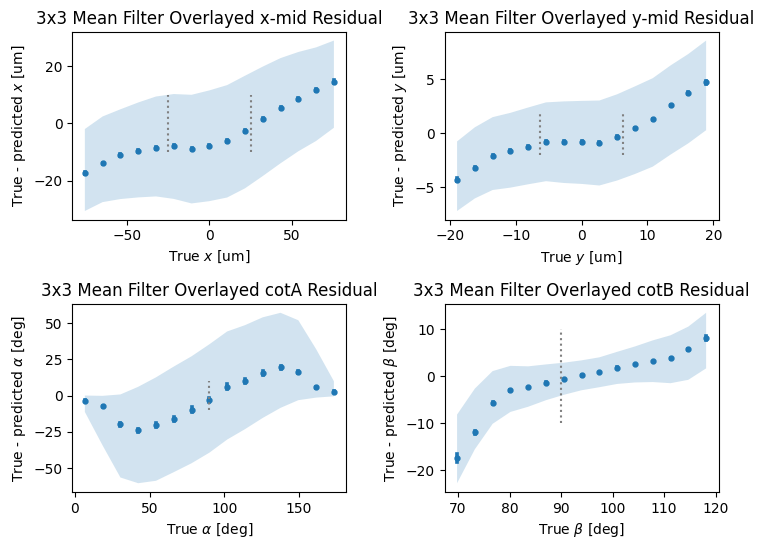

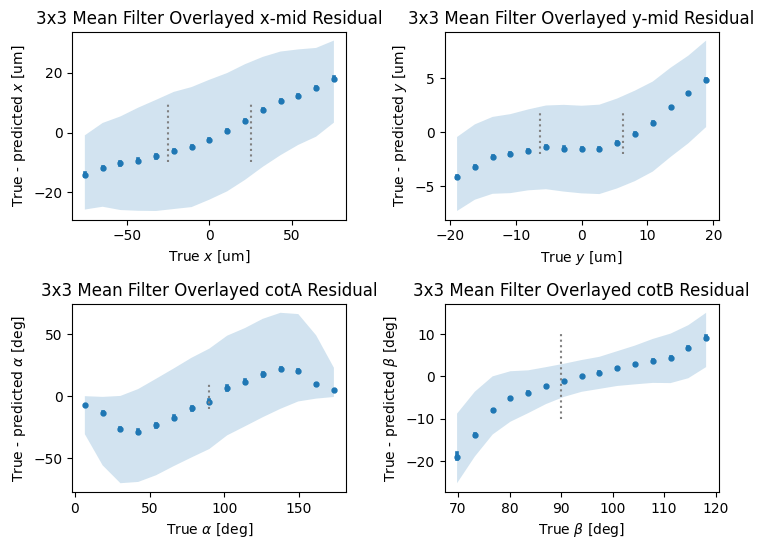

In [7]:
putlisthere = [2, 3, 4, 5, 6, 7]
for kern in putlisthere:
    df = pd.read_csv(f"test_3x3_{kern}x{kern}.csv")
    def residual_plot(ax, thisdf, var1, var2, name, title, scaling=1.0):
        
        nbins = 15
        
        var1_scaled = thisdf[var1] * scaling
        var2_scaled = thisdf[var2] * scaling
        residual_scaled = var1_scaled - var2_scaled
        
        xmin = np.min(var1_scaled)
        xmax = np.max(var1_scaled)
        
        step = 1.0*(xmax-xmin)/nbins
        
        x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
        ax.set_xlabel('True ' + name)
        ax.set_ylabel('True - predicted ' + name)
        ax.set_title(title)
        
        thisdf['residual'+var2] = residual_scaled
        print(var1)
        
        means = []
        upbar = []
        downbar = []
        for i in range(0,nbins):
            means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
            upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
            downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)
    
    def inverse_cot(cota):
        a = np.arctan(1.0/cota)
        a[np.where(a<0)] = a[np.where(a<0)] + pi
        return a    

    def residual_plot_deg(ax, thisdf, var1, var2, name, title, scaling=1.0):
        # positions
        if 'cot' not in var1:
            residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
            return
    
        thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
        
        thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
        thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
        thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
            
        var1 = 'angletrue'
        var2 = 'angle'
        
        nbins = 15
        xmin = np.min(thisdf[var1])
        xmax = np.max(thisdf[var1])
        
        step = 1.0*(xmax-xmin)/nbins
            
        x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
        ax.set_xlabel('True ' + name)
        ax.set_ylabel('True - predicted ' + name)
        ax.set_title(title)
        
        thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
        print(var1)
        
        means = []    
        upbar = []
        downbar = []
        for i in range(0,nbins):
            means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
            upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
            downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
        ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

    fig, axes = plt.subplots(2,2,figsize=(8,6))
    fig.tight_layout(pad=4.0)
    #residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', title=f"2x2, {kern}x{kern} x-mid Residual", scaling=75.0)   #different for mean filter
    residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', title=f"3x3 Mean Filter Overlayed x-mid Residual", scaling=75.0)   #different for mean filter removed 3x3, 
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    #residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', title=f"2x2, {kern}x{kern} y-mid Residual", scaling=18.75)   #different for mean filter
    residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', title=f"3x3 Mean Filter Overlayed y-mid Residual", scaling=18.75)   #different for mean filter
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    #residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"2x2, {kern}x{kern} cotA Residual", scaling=8.0)   #different for mean filter
    residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"3x3 Mean Filter Overlayed cotA Residual", scaling=8.0)   #different for mean filter
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    #residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"2x2, {kern}x{kern} cotB Residual", scaling=0.5)   #different for mean filter
    residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"3x3 Mean Filter Overlayed cotB Residual", scaling=0.5)   #different for mean filter
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

    #save_fig_path = os.path.join(base_dir, 'summary.png')
    #plt.savefig(save_fig_path)
    #plt.close()#################################################

xtrue
ytrue


/tmp/ipykernel_592/1082269563.py:41: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_592/1082269563.py:41: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
xtrue
ytrue


...

angletrue
xtrue
ytrue


/tmp/ipykernel_592/1082269563.py:41: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_592/1082269563.py:41: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


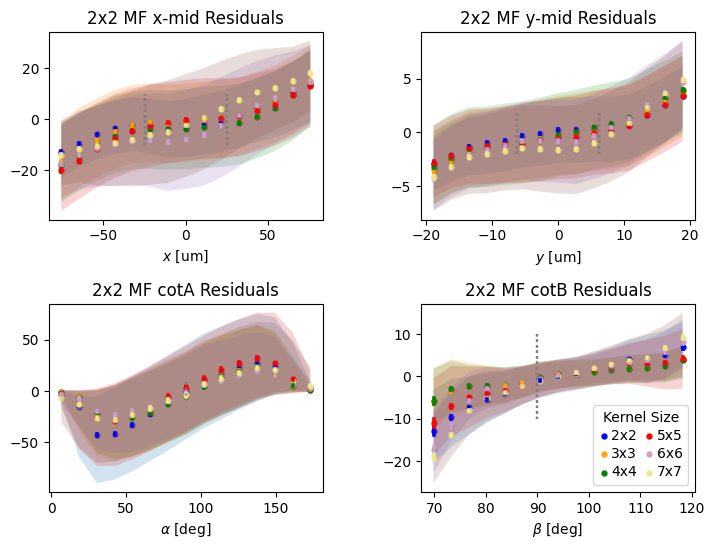

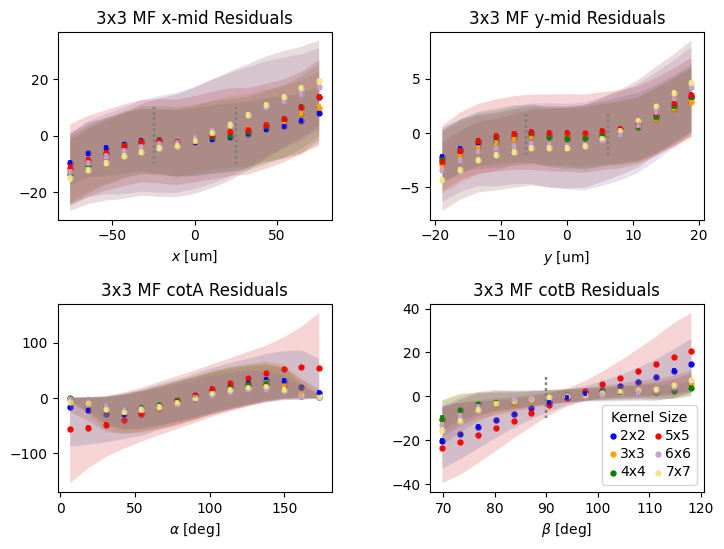

In [6]:
MFlist = [2, 3]
for MF in MFlist:
    df2 = pd.read_csv(f"test_{MF}x{MF}_2x2.csv")
    df3 = pd.read_csv(f"test_{MF}x{MF}_3x3.csv")
    df4 = pd.read_csv(f"test_{MF}x{MF}_4x4.csv")
    df5 = pd.read_csv(f"test_{MF}x{MF}_5x5.csv")
    df6 = pd.read_csv(f"test_{MF}x{MF}_6x6.csv")
    df7 = pd.read_csv(f"test_{MF}x{MF}_7x7.csv")
    def residual_plot(ax, thisdf, var1, var2, name, title, label, color, scaling=1.0):
        
        nbins = 15
        
        var1_scaled = thisdf[var1] * scaling
        var2_scaled = thisdf[var2] * scaling
        residual_scaled = var1_scaled - var2_scaled
        
        xmin = np.min(var1_scaled)
        xmax = np.max(var1_scaled)
        
        step = 1.0*(xmax-xmin)/nbins
        
        x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
        #ax.set_xlabel('True ' + name)
        ax.set_xlabel(name)
        #ax.set_ylabel('True - predicted ' + name)
        ax.set_title(title)
        
        thisdf['residual'+var2] = residual_scaled
        print(var1)
        
        means = []
        upbar = []
        downbar = []
        for i in range(0,nbins):
            means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
            upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
            downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)
    
    def inverse_cot(cota):
        a = np.arctan(1.0/cota)
        a[np.where(a<0)] = a[np.where(a<0)] + pi
        return a    
    
    def residual_plot_deg(ax, thisdf, var1, var2, name, title, label, color, scaling=1.0):
        # positions
        if 'cot' not in var1:
            residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
            return
    
        thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
        
        thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
        thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
        thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
            
        var1 = 'angletrue'
        var2 = 'angle'
        
        nbins = 15
        xmin = np.min(thisdf[var1])
        xmax = np.max(thisdf[var1])
        
        step = 1.0*(xmax-xmin)/nbins
            
        x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
        #ax.set_xlabel('True ' + name)
        ax.set_xlabel(name)
        #ax.set_ylabel('True - predicted ' + name)
        ax.set_title(title)
        
        thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
        print(var1)
        
        means = []    
        upbar = []
        downbar = []
        for i in range(0,nbins):
            means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
            upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
            downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
        ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)
    
    fig, axes = plt.subplots(2,2,figsize=(8,6))
    fig.tight_layout(pad=4.0)
    residual_plot(axes[0][0],df2,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='2x2', color='blue', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df2,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='2x2', color='blue', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df2,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='2x2', color='blue', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df2,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"{MF}x{MF} MF cotB Residuals", label='2x2', color='blue', scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
    #
    residual_plot(axes[0][0],df3,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='3x3', color='orange', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df3,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='3x3', color='orange', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df3,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='3x3', color='orange', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df3,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"{MF}x{MF} MF cotB Residuals", label='3x3', color='orange', scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

    residual_plot(axes[0][0],df4,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='4x4', color='green', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df4,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='4x4', color='green', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df4,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='4x4', color='green', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df4,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"{MF}x{MF} MF cotB Residuals", label='4x4', color='green', scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
    #
    residual_plot(axes[0][0],df5,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='5x5', color='red', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df5,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='5x5', color='red', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df5,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='5x5', color='red', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df5,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"{MF}x{MF} MF cotB Residuals", label='5x5', color='red', scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
    #
    residual_plot(axes[0][0],df6,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='6x6', color='#C8A2C8', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df6,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='6x6', color='#C8A2C8', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df6,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='6x6', color='#C8A2C8', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df6,'cotBtrue','cotB',r'$\beta$ [deg]', title=f"{MF}x{MF} MF cotB Residuals", label='6x6', color='#C8A2C8', scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
    #
    residual_plot(axes[0][0],df7,'xtrue','x',r'$x$ [um]', title=f"{MF}x{MF} MF x-mid Residuals", label='7x7', color='#F0E68C', scaling=75.0)
    axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes[0][1],df7,'ytrue','y',r'$y$ [um]', title=f"{MF}x{MF} MF y-mid Residuals", label='7x7', color='#F0E68C', scaling=18.75)
    axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes[1][0],df7,'cotAtrue','cotA',r'$\alpha$ [deg]', title=f"{MF}x{MF} MF cotA Residuals", label='7x7', color='#F0E68C', scaling=8.0)
    axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes[1][1],df7,'cotBtrue','cotB',r'$\beta$ [deg]',title=f"{MF}x{MF} MF cotB Residuals",label='7x7',color='#F0E68C',scaling=0.5)
    axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
    
    plt.legend(loc='lower right', title='Kernel Size', ncol=2, columnspacing=0.5, handlelength=0.7, handletextpad=0.2, labelspacing=0.3)
    #save_fig_path = os.path.join(base_dir, 'summary.png')
    #plt.savefig(save_fig_path)
    #plt.close()################################################A

xtrue
ytrue


/tmp/ipykernel_732223/1723728765.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_732223/1723728765.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
xtrue
ytrue


...

angletrue
xtrue
ytrue


/tmp/ipykernel_732223/1723728765.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_732223/1723728765.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


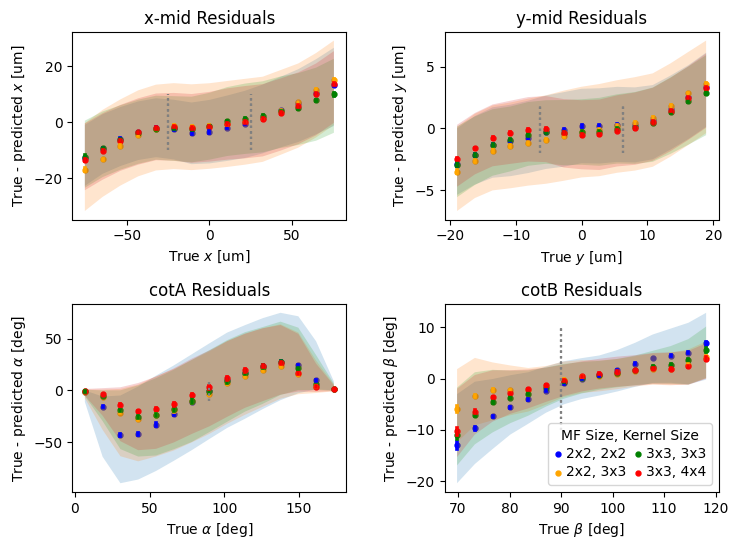

In [25]:
df2 = pd.read_csv('test_2x2_2x2.csv')
df3 = pd.read_csv('test_2x2_3x3.csv')
df4 = pd.read_csv('test_3x3_3x3.csv')
df5 = pd.read_csv('test_3x3_4x4.csv')
def residual_plot(ax, thisdf, var1, var2, name, title, label, color, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    ax.set_title(title)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, title, label, color, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    ax.set_title(title)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df2,'xtrue','x',r'$x$ [um]', title='x-mid Residuals', label='2x2, 2x2', color='blue', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df2,'ytrue','y',r'$y$ [um]', title='y-mid Residuals', label='2x2, 2x2', color='blue', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df2,'cotAtrue','cotA',r'$\alpha$ [deg]', title='cotA Residuals', label='2x2, 2x2', color='blue', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df2,'cotBtrue','cotB',r'$\beta$ [deg]', title='cotB Residuals', label='2x2, 2x2', color='blue', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
#
residual_plot(axes[0][0],df3,'xtrue','x',r'$x$ [um]', title='x-mid Residuals', label='2x2, 3x3', color='orange', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df3,'ytrue','y',r'$y$ [um]', title='y-mid Residuals', label='2x2, 3x3', color='orange', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df3,'cotAtrue','cotA',r'$\alpha$ [deg]', title='cotA Residuals', label='2x2, 3x3', color='orange', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df3,'cotBtrue','cotB',r'$\beta$ [deg]', title='cotB Residuals', label='2x2, 3x3', color='orange', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
#
residual_plot(axes[0][0],df4,'xtrue','x',r'$x$ [um]', title='x-mid Residuals', label='3x3, 3x3', color='green', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df4,'ytrue','y',r'$y$ [um]', title='y-mid Residuals', label='3x3, 3x3', color='green', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df4,'cotAtrue','cotA',r'$\alpha$ [deg]', title='cotA Residuals', label='3x3, 3x3', color='green', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df4,'cotBtrue','cotB',r'$\beta$ [deg]', title='cotB Residuals', label='3x3, 3x3', color='green', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
#
residual_plot(axes[0][0],df5,'xtrue','x',r'$x$ [um]', title='x-mid Residuals', label='3x3, 4x4', color='red', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df5,'ytrue','y',r'$y$ [um]', title='y-mid Residuals', label='3x3, 4x4', color='red', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df5,'cotAtrue','cotA',r'$\alpha$ [deg]', title='cotA Residuals', label='3x3, 4x4', color='red', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df5,'cotBtrue','cotB',r'$\beta$ [deg]', title='cotB Residuals', label='3x3, 4x4', color='red', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

plt.legend(loc='lower right', title='MF Size, Kernel Size', ncol=2, columnspacing=0.5, handlelength=0.7, handletextpad=0.2, labelspacing=0.3)
#save_fig_path = os.path.join(base_dir, 'summary.png')
#plt.savefig(save_fig_path)
#plt.close()################################################A

xtrue
ytrue


/tmp/ipykernel_592/1096210657.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_592/1096210657.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
xtrue
ytrue


...

angletrue


/tmp/ipykernel_592/1096210657.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
xtrue
ytrue


/tmp/ipykernel_592/1096210657.py:36: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
angletrue


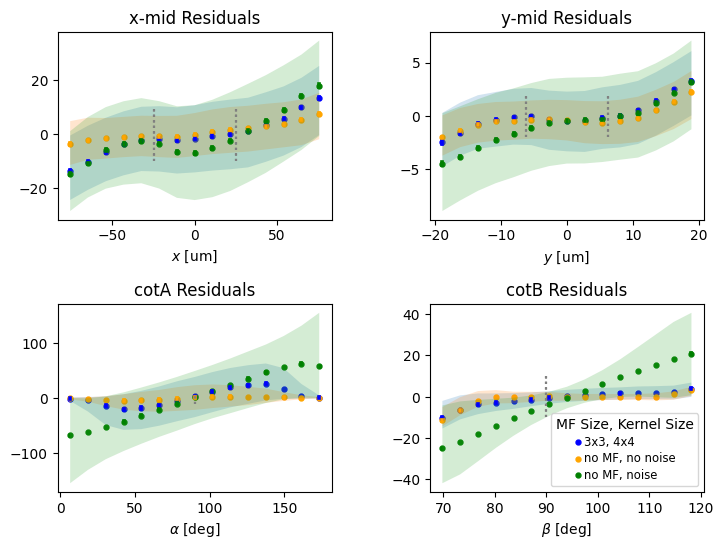

In [5]:
df2 = pd.read_csv('test_3x3_4x4.csv')
df3 = pd.read_csv('test_no_noise_3x3.csv')
df4 = pd.read_csv('test_noise_3x3.csv')
def residual_plot(ax, thisdf, var1, var2, name, label, title, color, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
    #ax.set_xlabel('True ' + name)
    ax.set_xlabel(name)
    #ax.set_ylabel('True - predicted ' + name)
    ax.set_title(title)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, label, title, color, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color=color)
    #ax.set_xlabel('True ' + name)
    ax.set_xlabel(name)
    #ax.set_ylabel('True - predicted ' + name)
    ax.set_title(title)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df2,'xtrue','x','x [um]', label='3x3, 4x4', title='x-mid Residuals', color='blue', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df2,'ytrue','y',r'$y$ [um]', label='3x3, 4x4', title='y-mid Residuals', color='blue', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df2,'cotAtrue','cotA',r'$\alpha$ [deg]', label='3x3, 4x4', title='cotA Residuals', color='blue', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df2,'cotBtrue','cotB',r'$\beta$ [deg]', label='3x3, 4x4', title='cotB Residuals', color='blue', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
#
residual_plot(axes[0][0],df3,'xtrue','x',r'$x$ [um]', label='no MF, no noise', title='x-mid Residuals', color='orange', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df3,'ytrue','y',r'$y$ [um]', label='no MF, no noise', title='y-mid Residuals', color='orange', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df3,'cotAtrue','cotA',r'$\alpha$ [deg]', label='no MF, no noise', title='cotA Residuals', color='orange', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df3,'cotBtrue','cotB',r'$\beta$ [deg]', label='no MF, no noise', title='cotB Residuals', color='orange', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')
#
residual_plot(axes[0][0],df4,'xtrue','x',r'$x$ [um]', label='no MF, noise', title='x-mid Residuals', color='green', scaling=75.0)
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df4,'ytrue','y',r'$y$ [um]', label='no MF, noise', title='y-mid Residuals', color='green', scaling=18.75)
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df4,'cotAtrue','cotA',r'$\alpha$ [deg]', label='no MF, noise', title='cotA Residuals', color='green', scaling=8.0)
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df4,'cotBtrue','cotB',r'$\beta$ [deg]', label='no MF, noise', title='cotB Residuals', color='green', scaling=0.5)
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

plt.legend(loc='lower right', title='MF Size, Kernel Size', ncol=1, handlelength=0.7, handletextpad=0.2, labelspacing=0.3, fontsize='small')
#save_fig_path = os.path.join(base_dir, 'summary.png')
#plt.savefig(save_fig_path)
#plt.close()################################################A